In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statistics import mode
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler 

In [23]:
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,NaN,72.0,35.0,0.0,NaN,0.627,NaN,1
1,1.0,85.0,66.0,29.0,0.0,NaN,0.351,31.0,0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0
4,0.0,NaN,40.0,35.0,168.0,43.1,NaN,33.0,1
...,...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,0.171,NaN,0
764,2.0,122.0,70.0,27.0,0.0,36.8,0.340,27.0,0
765,5.0,121.0,72.0,23.0,NaN,26.2,0.245,30.0,0
766,1.0,126.0,60.0,0.0,0.0,30.1,NaN,47.0,1


1. Imputasi missing value dengan mean, median, dan modus

In [6]:
# Periksa missing valuenya
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Pregnancies                  77
Glucose                     115
BloodPressure               154
SkinThickness                38
Insulin                     192
BMI                         230
DiabetesPedigreeFunction     77
Age                         154
Outcome                       0
dtype: int64


In [13]:
# Impute missing values dengan mean
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean())
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].mean())
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].mean())
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Impute missing values dengan median
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].median())
df['DiabetesPedigreeFunction'] = df['DiabetesPedigreeFunction'].fillna(df['DiabetesPedigreeFunction'].median())

# Impute missing values dengan modus
df['Pregnancies'] = df['Pregnancies'].fillna(mode(df['Pregnancies']))
df['Outcome'] = df['Outcome'].fillna(mode(df['Outcome']))

# Cetak dataframe yang telah diimputasi
print(df)

     Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0            6.0  120.462481           72.0           35.0    0.000000   
1            1.0   85.000000           66.0           29.0    0.000000   
2            8.0  183.000000           64.0            0.0    0.000000   
3            1.0   89.000000           66.0           23.0   94.000000   
4            0.0  120.462481           40.0           35.0  168.000000   
..           ...         ...            ...            ...         ...   
763         10.0  101.000000           76.0           48.0  180.000000   
764          2.0  122.000000           70.0           27.0    0.000000   
765          5.0  121.000000           72.0           23.0   76.878472   
766          1.0  126.000000           60.0            0.0    0.000000   
767          1.0   93.000000           72.0           31.0    0.000000   

          BMI  DiabetesPedigreeFunction        Age  Outcome  
0    31.99368                     0.627  33.16612

2. Cek korelasi antar variabel dengan heatmap

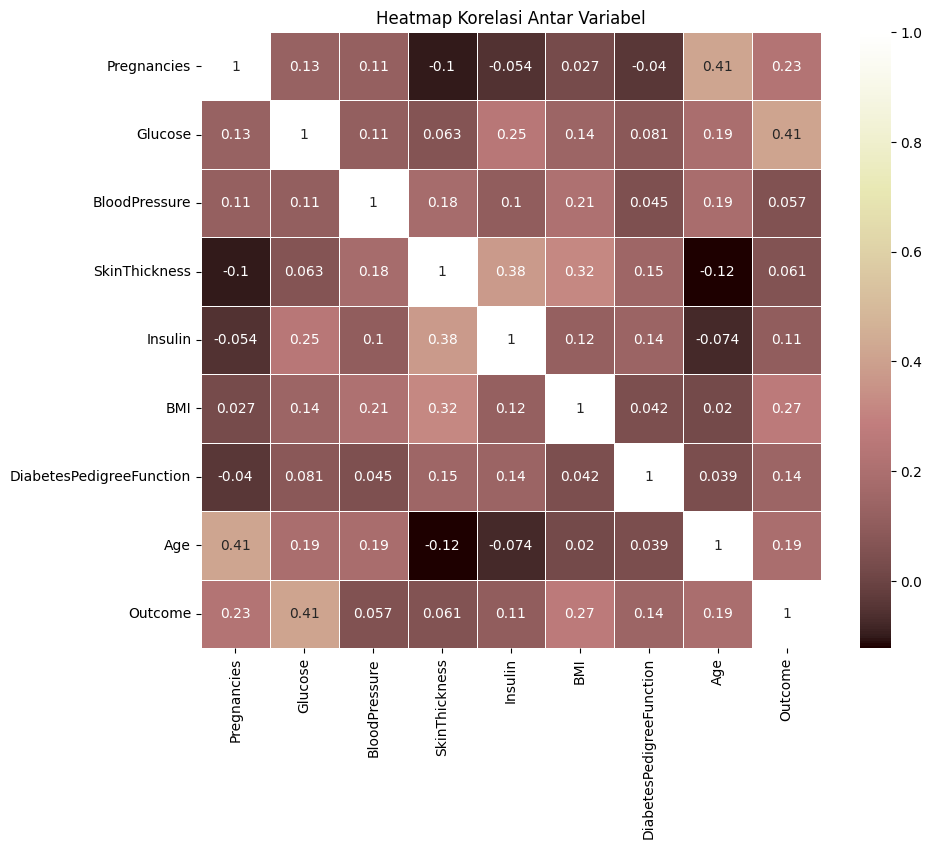

In [14]:
corr_matrix = df.corr() #Untuk menghitung matriks korelasi

# Untuk membuat heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='pink', linewidths=0.5)

# Untuk menampilkan heatmap
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()


3. Lakukan imbalance handling dengan undersampling

In [15]:
# Memisahkan fitur dan target
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# Menangani missing values (jika ada)
X.fillna(X.mean(), inplace=True)

# Melakukan undersampling
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

# Membuat DataFrame baru dari hasil undersampling
resampled_data = pd.DataFrame(X_resampled, columns=X.columns)
resampled_data['Outcome'] = y_resampled

# Menampilkan informasi tentang data hasil resampling
print(resampled_data['Outcome'].value_counts())

Outcome
0    268
1    268
Name: count, dtype: int64


4. Lakukan scaling dengan robust scaler dan minmax

In [17]:
# Untuk memisahkan fitur dan target
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# Untuk menggunakan RobustScaler
robust_scaler = RobustScaler()
X_robust_scaled = robust_scaler.fit_transform(X)

# Untuk menggunakan MinMaxScaler
minmax_scaler = MinMaxScaler()
X_minmax_scaled = minmax_scaler.fit_transform(X)

# Untuk mengonversi kembali ke DataFrame untuk kemudahan analisis
X_robust_scaled_df = pd.DataFrame(X_robust_scaled, columns=X.columns)
X_minmax_scaled_df = pd.DataFrame(X_minmax_scaled, columns=X.columns)

# Untuk menampilkan hasil
print("Data setelah Robust Scaling:")
print(X_robust_scaled_df.head())

print("\nData setelah MinMax Scaling:")
print(X_minmax_scaled_df.head())

Data setelah Robust Scaling:
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0          0.6       NaN       0.000000        0.37500 -0.298755       NaN   
1         -0.4 -0.756098      -0.333333        0.18750 -0.298755       NaN   
2          1.0  1.634146      -0.444444       -0.71875 -0.298755 -0.961957   
3         -0.4 -0.658537      -0.333333        0.00000  0.481328 -0.440217   
4         -0.6       NaN      -1.777778        0.37500  1.095436  1.190217   

   DiabetesPedigreeFunction     Age  
0                  0.675258     NaN  
1                 -0.036082  0.1250  
2                  0.791237  0.1875  
3                 -0.510309 -0.5000  
4                       NaN  0.2500  

Data setelah MinMax Scaling:
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.352941       NaN       0.631579       0.353535  0.000000       NaN   
1     0.058824  0.427136       0.578947       0.292929  0.000000       NaN   
2     0.47